# Road Damage Detection

Detects:
- D00 Longitudinal crack
- D10 Transverse crack
- D20 Alligator crack
- D40 Pothole

Model: YOLO11n

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [2]:
from pathlib import Path
import shutil
import random
import subprocess
import sys

DATA = Path(r"D:\Programs\Python\Road_Damage\RDD2022-India.v6-rdd2022-india-aug.yolov11")
OUT = Path(r"D:\Programs\Python\Road_Damage\RDD2022-India.v6-rdd2022-india-aug.yolov11\RDD2022-India-4class")

FAST = True
MAX_TRAIN = 4000
MAX_VAL = 800
MAX_TEST = 800

print("Dataset:", DATA)
print("Output:", OUT)

Dataset: D:\Programs\Python\Road_Damage\RDD2022-India.v6-rdd2022-india-aug.yolov11
Output: D:\Programs\Python\Road_Damage\RDD2022-India.v6-rdd2022-india-aug.yolov11\RDD2022-India-4class


In [3]:
if not DATA.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATA}"
    )

for split in ["train", "valid", "test"]:
    image_dir = DATA / split / "images"
    label_dir = DATA / split / "labels"

    print(
        split,
        "images:", len(list(image_dir.glob("*"))),
        "labels:", len(list(label_dir.glob("*.txt")))
    )

train images: 14118 labels: 14118
valid images: 2240 labels: 2240
test images: 760 labels: 760


In [4]:
class_map = {
    0: 0,   # D00
    3: 1,   # D10
    5: 2,   # D20
    6: 3    # D40
}

names = [
    "D00_Longitudinal_Crack",
    "D10_Transverse_Crack",
    "D20_Alligator_Crack",
    "D40_Pothole"
]

random.seed(42)

def make_split(split, limit=None):
    image_dir = DATA / split / "images"
    label_dir = DATA / split / "labels"

    out_images = OUT / split / "images"
    out_labels = OUT / split / "labels"

    out_images.mkdir(parents=True, exist_ok=True)
    out_labels.mkdir(parents=True, exist_ok=True)

    image_files = [
        p for p in image_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    ]

    # Keep only images that contain at least one of the 4 required classes.
    good_images = []

    for image_path in image_files:
        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            continue

        has_target = False

        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 5 and int(parts[0]) in class_map:
                    has_target = True
                    break

        if has_target:
            good_images.append(image_path)

    random.shuffle(good_images)

    if limit is not None:
        good_images = good_images[:limit]

    box_count = 0

    for image_path in good_images:
        label_path = label_dir / f"{image_path.stem}.txt"

        new_lines = []

        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                old_id = int(parts[0])

                if old_id not in class_map:
                    continue

                new_id = class_map[old_id]
                new_lines.append(
                    " ".join([str(new_id)] + parts[1:])
                )
                box_count += 1

        if not new_lines:
            continue

        shutil.copy2(
            image_path,
            out_images / image_path.name
        )

        with open(
            out_labels / f"{image_path.stem}.txt",
            "w",
            encoding="utf-8"
        ) as f:
            f.write("\n".join(new_lines) + "\n")

    return len(good_images), box_count


limits = {
    "train": MAX_TRAIN if FAST else None,
    "valid": MAX_VAL if FAST else None,
    "test": MAX_TEST if FAST else None
}

for split in ["train", "valid", "test"]:
    count, boxes = make_split(
        split,
        limits[split]
    )
    print(
        split,
        "images:", count,
        "boxes:", boxes
    )

train images: 4000 boxes: 8427
valid images: 800 boxes: 1733
test images: 313 boxes: 682


In [5]:
import yaml

yaml_data = {
    "path": str(OUT.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 4,
    "names": names
}

yaml_path = OUT / "data.yaml"

with open(
    yaml_path,
    "w",
    encoding="utf-8"
) as f:
    yaml.dump(
        yaml_data,
        f,
        sort_keys=False
    )

print(yaml_path)
print("\n" + yaml.dump(yaml_data, sort_keys=False))

D:\Programs\Python\Road_Damage\RDD2022-India.v6-rdd2022-india-aug.yolov11\RDD2022-India-4class\data.yaml

path: D:\Programs\Python\Road_Damage\RDD2022-India.v6-rdd2022-india-aug.yolov11\RDD2022-India-4class
train: train/images
val: valid/images
test: test/images
nc: 4
names:
- D00_Longitudinal_Crack
- D10_Transverse_Crack
- D20_Alligator_Crack
- D40_Pothole



In [6]:
# Quick check of the new labels

from collections import Counter

counts = Counter()

for split in ["train", "valid", "test"]:
    label_dir = OUT / split / "labels"

    for label_file in label_dir.glob("*.txt"):
        with open(
            label_file,
            "r",
            encoding="utf-8"
        ) as f:
            for line in f:
                if line.strip():
                    counts[int(line.split()[0])] += 1

print("Class counts:")

for i, name in enumerate(names):
    print(
        i,
        name,
        counts[i]
    )

Class counts:
0 D00_Longitudinal_Crack 2509
1 D10_Transverse_Crack 110
2 D20_Alligator_Crack 3162
3 D40_Pothole 5061


In [7]:
# Install Ultralytics

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "ultralytics"
])

print("Ultralytics installed.")

Ultralytics installed.


In [8]:
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else "cpu"

print("Device:", device)

model = YOLO("yolo11n.pt")
print("Model loaded.")

Device: 0
Model loaded.


In [9]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.14.0+cu130
CUDA available: True
CUDA version: 13.0
GPU count: 1
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [10]:
if torch.cuda.is_available():
    epochs = 8
    batch = 16
else:
    epochs = 8
    batch = 4

print("Epochs:", epochs)
print("Batch:", batch)

train_results = model.train(
    data=str(yaml_path),
    epochs=epochs,
    imgsz=640,
    batch=batch,
    device=device,
    workers=2,
    patience=3,
    pretrained=True,
    project="road_damage_runs",
    name="yolo11n_rdd2022_india",
    exist_ok=True,
    verbose=True
)

Epochs: 8
Batch: 16
Ultralytics 8.4.165  Python-3.13.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8123MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Programs\Python\Road_Damage\RDD2022-India.v6-rdd2022-india-aug.yolov11\RDD2022-India-4class\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo1

In [11]:
metrics = model.val(
    data=str(yaml_path),
    imgsz=640,
    device=device
)

print("Validation complete.")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.165  Python-3.13.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8123MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.30.0 ms, read: 94.723.7 MB/s, size: 41.6 KB)
val: Scanning D:\Programs\Python\Road_Damage\RDD2022-India.v6-rdd2022-india-aug.yolov11\RDD2022-India-4class\valid\labels.cache... 800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 145.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 1.6it/s 31.4s0.3ss
                   all        800       1733      0.588      0.277      0.278      0.115
D00_Longitudinal_Crack        277        411      0.378      0.217      0.229     0.0907
  D10_Transverse_Crack         17         20          1          0          0          0
   D20_Alligator_Crack        444        516      0.554      0.527      0.547       0.25
           D40_Pothole        36

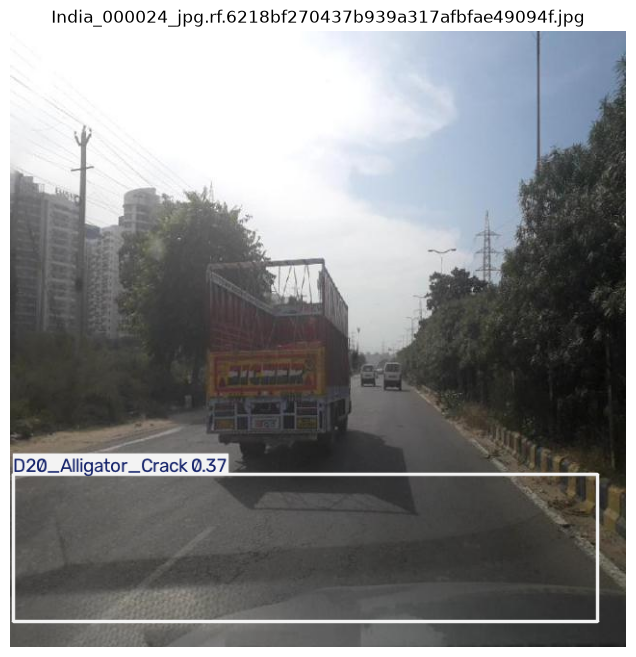

In [12]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

test_images = list(
    (OUT / "test" / "images").glob("*")
)

if not test_images:
    raise RuntimeError("No test images found.")

img_path = test_images[0]

pred = model.predict(
    source=str(img_path),
    conf=0.25,
    imgsz=640,
    device=device,
    verbose=False
)

img = pred[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(img[:, :, ::-1])
plt.axis("off")
plt.title(img_path.name)
plt.show()

In [13]:
# Single-image prediction + severity estimate

import pandas as pd
import numpy as np

severity_base = {
    "D00_Longitudinal_Crack": 0.10,
    "D10_Transverse_Crack": 0.12,
    "D20_Alligator_Crack": 0.25,
    "D40_Pothole": 0.22
}

def get_severity(class_name, box_area, image_area, total_boxes):
    area_ratio = box_area / max(image_area, 1)

    score = (
        0.55 * area_ratio
        + severity_base.get(class_name, 0.10)
        + 0.05 * min(total_boxes, 4)
    )

    if score < 0.16:
        return "Low"

    if score < 0.30:
        return "Medium"

    return "High"


rows = []

image = Image.open(img_path)
image_area = image.width * image.height

boxes = pred[0].boxes
total_boxes = len(boxes)

for i in range(total_boxes):

    xyxy = boxes.xyxy[i].cpu().numpy()

    x1, y1, x2, y2 = xyxy

    box_area = max(
        0,
        x2 - x1
    ) * max(
        0,
        y2 - y1
    )

    class_id = int(
        boxes.cls[i].item()
    )

    confidence = float(
        boxes.conf[i].item()
    )

    class_name = names[class_id]

    severity = get_severity(
        class_name,
        box_area,
        image_area,
        total_boxes
    )

    rows.append({
        "damage": class_name,
        "confidence": round(
            confidence,
            3
        ),
        "severity": severity,
        "box_area_ratio": round(
            box_area / image_area,
            4
        )
    })

results_df = pd.DataFrame(rows)

display(results_df)

,damage,confidence,severity,box_area_ratio
0,D20_Alligator_Crack,0.368,High,0.2269


In [14]:
# Run on all test images

test_results = []

for image_path in test_images[:100]:
    results = model.predict(
        source=str(image_path),
        conf=0.25,
        imgsz=640,
        device=device,
        verbose=False
    )

    result = results[0]
    boxes = result.boxes

    if len(boxes) == 0:
        continue

    image = Image.open(image_path)
    image_area = image.width * image.height

    for i in range(len(boxes)):

        xyxy = boxes.xyxy[i].cpu().numpy()

        x1, y1, x2, y2 = xyxy

        box_area = max(
            0,
            x2 - x1
        ) * max(
            0,
            y2 - y1
        )

        class_id = int(
            boxes.cls[i].item()
        )

        confidence = float(
            boxes.conf[i].item()
        )

        class_name = names[class_id]

        severity = get_severity(
            class_name,
            box_area,
            image_area,
            len(boxes)
        )

        test_results.append({
            "image": image_path.name,
            "damage": class_name,
            "confidence": round(
                confidence,
                3
            ),
            "severity": severity
        })

all_results = pd.DataFrame(test_results)

all_results.to_csv(
    "road_damage_predictions.csv",
    index=False
)

display(all_results.head(20))

print(
    "Saved road_damage_predictions.csv"
)

,image,damage,confidence,severity
0,India_000024_jpg.rf.6218bf270437b939a317afbfae...,D20_Alligator_Crack,0.368,High
1,India_000052_jpg.rf.2fa5ca13afc8baf63b553a6148...,D40_Pothole,0.531,High
2,India_000052_jpg.rf.2fa5ca13afc8baf63b553a6148...,D20_Alligator_Crack,0.435,High
3,India_000052_jpg.rf.2fa5ca13afc8baf63b553a6148...,D40_Pothole,0.367,High
4,India_000052_jpg.rf.2fa5ca13afc8baf63b553a6148...,D40_Pothole,0.357,High
5,India_000052_jpg.rf.2fa5ca13afc8baf63b553a6148...,D40_Pothole,0.292,High
6,India_000052_jpg.rf.2fa5ca13afc8baf63b553a6148...,D00_Longitudinal_Crack,0.288,High
7,India_000067_jpg.rf.4e06e19ad38a2c011523093765...,D20_Alligator_Crack,0.275,High
8,India_000067_jpg.rf.4e06e19ad38a2c011523093765...,D40_Pothole,0.269,High
9,India_000114_jpg.rf.923f8e6dca1f7019d54777c820...,D20_Alligator_Crack,0.689,High


Saved road_damage_predictions.csv


In [15]:
# Save the trained model

model_path = Path(
    "road_damage_yolo11n.pt"
)

model.save(
    str(model_path)
)

print(
    "Saved model:",
    model_path.resolve()
)

Saved model: D:\Programs\Python\Road_Damage\RDD2022-India.v6-rdd2022-india-aug.yolov11\road_damage_yolo11n.pt


### Output

The main outputs are:

- trained YOLO11n model
- annotated predictions
- validation metrics
- `road_damage_predictions.csv`

Severity is an **estimated heuristic**, not a separately trained severity model, because the supplied dataset labels damage type rather than Low/Medium/High severity.